In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import joblib

In [4]:
fake = pd.read_csv(r'C:\Users\DELL\misinformation-detector\data\Fake.csv')
real = pd.read_csv(r'C:\Users\DELL\misinformation-detector\data\True.csv')

fake['label'] = 0
real['label'] = 1

df = pd.concat([fake, real], ignore_index=True)
df = df[['title', 'label']].dropna()  # headlines only
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Dataset size: {len(df)} headlines")
print(f"Fake: {len(df[df.label==0])} | Real: {len(df[df.label==1])}")

Dataset size: 44898 headlines
Fake: 23481 | Real: 21417


In [5]:
# ── 2. Split ───────────────────────────────────────────────
# Ng always emphasizes: split BEFORE any processing
X = df['title']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance in both splits
)

print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 35918 | Test size: 8980


In [6]:
# ── 3. Build Pipeline ──────────────────────────────────────
# TF-IDF converts text → numbers
# Logistic Regression classifies the numbers
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',   # remove 'the', 'is', 'at' etc.
        ngram_range=(1, 2),     # unigrams + bigrams
        max_features=10000,     # top 10k most important words
        min_df=2                # ignore very rare words
    )),
    ('clf', LogisticRegression(
        C=1.0,                  
        max_iter=1000,
        random_state=42
    ))
])

In [7]:
# ── 4. Train ───────────────────────────────────────────────
print("\nTraining model...")
pipeline.fit(X_train, y_train)
print("Done!")


Training model...
Done!


In [8]:
# ── 5. Evaluate ────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]  # confidence scores

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['Fake','Real']))

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


── Classification Report ──
              precision    recall  f1-score   support

        Fake       0.96      0.94      0.95      4696
        Real       0.93      0.95      0.94      4284

    accuracy                           0.94      8980
   macro avg       0.94      0.95      0.94      8980
weighted avg       0.95      0.94      0.95      8980

Precision : 0.9323
Recall    : 0.9540
F1 Score  : 0.9430


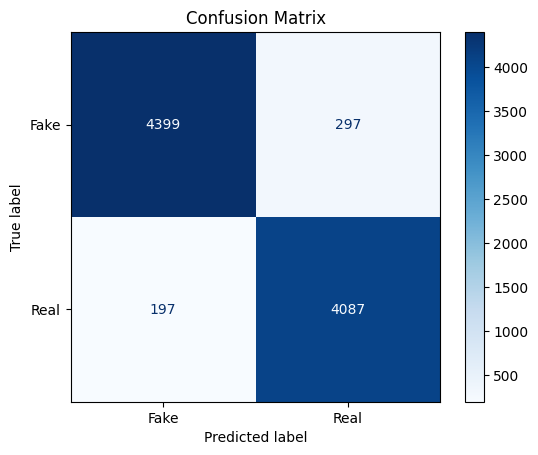

In [9]:
# ── 6. Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fake','Real'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('model/confusion_matrix.png')
plt.show()

In [10]:
# ── 7. Top TF-IDF Features ────────────────────────────────
# See WHICH words drive fake vs real predictions
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefficients  = pipeline.named_steps['clf'].coef_[0]

top_fake = np.argsort(coefficients)[:15]   # most negative = fake
top_real = np.argsort(coefficients)[-15:]  # most positive = real

print("\nTop words → FAKE:")
for i in top_fake:
    print(f"  {feature_names[i]:30s} {coefficients[i]:.3f}")

print("\nTop words → REAL:")
for i in top_real:
    print(f"  {feature_names[i]:30s} {coefficients[i]:.3f}")


Top words → FAKE:
  video                          -18.918
  hillary                        -8.906
  watch                          -8.740
  breaking                       -8.345
  gop                            -7.953
  just                           -7.763
  tweets                         -4.711
  america                        -4.607
  racist                         -4.370
  details                        -4.232
  president trump                -4.172
  obama                          -4.029
  muslim                         -3.917
  isis                           -3.905
  wow                            -3.751

Top words → REAL:
  opposition                     3.229
  seek                           3.238
  lawmakers                      3.240
  islamic state                  3.244
  eu                             3.297
  ex                             3.366
  brexit                         3.368
  house                          3.484
  talks                          3.595
  senate  

In [11]:
# ── 8. Save Model ──────────────────────────────────────────
joblib.dump(pipeline, 'model/pipeline.pkl')
print("\nModel saved to model/pipeline.pkl")



Model saved to model/pipeline.pkl
